# Nash Bargaining and Wage Determination

## Introduction

In competitive labor markets, wages are determined by market clearing: supply equals demand. In the search and matching model, this mechanism is unavailable. Matching frictions mean that when a worker and a firm meet, they find themselves in a bilateral relationship with no market price to coordinate on. The wage must instead be determined by negotiation.

These notes review the theory of Nash bargaining and applies it to wage determination in the search and matching model. First, we present the axiomatic foundations of the Nash bargaining solution — the four properties that any reasonable bargaining outcome should satisfy, and the theorem that characterizes the unique solution satisfying all four. Second, we connect the Nash solution to the labor market by identifying the surpluses and threat points of workers and firms. Third, we derive the equilibrium wage equation and provide an economic interpretation.

## The Nash Bargaining Problem

A bargaining problem consists of two objects:

- A **feasible set** $U \subset \mathbb{R}^2$: the set of utility pairs $(u_1, u_2)$ that the two players can jointly achieve through some agreement.
- A **disagreement point** $d = (d_1, d_2) \in \mathbb{R}^2$: the utility pair that each player receives if no agreement is reached — the outside option, or threat point.

A **bargaining solution** is a function $f: (U, d) \mapsto (u_1, u_2)$ that selects a particular outcome from the feasible set. Rather than modeling an explicit negotiation game, Nash (1950) took an axiomatic approach.  He specified four properties that any reasonable bargaining solution should satisfy, and showed that there exists a unique solution which satisfies all four properties.

### The Four Axioms

**Axiom 1: Invariance to affine transformations.** The bargaining solution should not depend on the units in which utility is measured. Formally, if we transform the utility functions by any affine mapping — replacing $u_i$ with $\alpha_i u_i + \beta_i$ for constants $\alpha_i > 0$ and $\beta_i$ — the solution should transform in the same way:

$$f_i(U') = \alpha_i f_i(U) + \beta_i$$

where $U' = \{(\alpha_1 u_1 + \beta_1, \alpha_2 u_2 + \beta_2) \mid (u_1, u_2) \in U\}$. This axiom formalizes the idea that the bargaining outcome reflects the underlying preferences of the players, not the arbitrary scaling of their utility representations.

**Axiom 2: Pareto optimality.** The solution must be Pareto efficient. There should be no agreement $u' \in U$ such that $u' \geq f(U)$ with strict inequality for at least one player. A solution that leaves a Pareto improvement on the table is implausible — the players would have an incentive to renegotiate to the dominating outcome.

**Axiom 3: Independence of irrelevant alternatives.** Consider two bargaining problems with feasible sets $U' \subseteq U$. If the solution to the larger problem lies within the smaller set — $f(U) \in U'$ — then the solution to the smaller problem should be the same: $f(U') = f(U)$. Removing agreements that would never be chosen anyway should not affect the outcome.

**Axiom 4: Symmetry.** If the bargaining problem is symmetric — $(u_1, u_2) \in U$ if and only if $(u_2, u_1) \in U$, and $d_1 = d_2$ — then the solution should treat the players equally: $f_1(U) = f_2(U)$. Players who look identical should receive identical payoffs.

### The Nash Bargaining Theorem

```{admonition} Theorem: Nash Bargaining Solution
:class: important
The **unique** bargaining solution satisfying Axioms 1–4 is the **Nash bargaining solution**:

$$\max_{(u_1, u_2) \in U} (u_1 - d_1)(u_2 - d_2)$$

subject to $(u_1, u_2) \geq (d_1, d_2)$.
```

The Nash solution selects the agreement that maximizes the product of the players' surpluses above their disagreement payoffs. The geometric interpretation is instructive: the solution lies at the point on the Pareto frontier of $U$ where the hyperbola $(u_1 - d_1)(u_2 - d_2) = c$ is tangent to the feasible set, for the highest attainable $c$.

It is worth noting that Nash's axiomatic approach has a strategic foundation. Rubinstein (1982) showed that the Nash solution emerges as the unique subgame perfect equilibrium of an alternating-offer bargaining game in which players discount time at rate $r$ and the probability of breakdown is $\delta$, in the limit as $\delta \to 0$. The axioms are therefore not merely normative desiderata — they have a game-theoretic rationalization.

### Asymmetric Nash Bargaining

The symmetry axiom (Axiom 4) can be relaxed to allow for asymmetric bargaining power. The **asymmetric Nash bargaining solution** assigns bargaining power $\alpha \in (0, 1)$ to Player 1 and $1 - \alpha$ to Player 2:

$$\max_{(u_1, u_2) \in U}\; (u_1 - d_1)^\alpha (u_2 - d_2)^{1-\alpha}$$

subject to $(u_1, u_2) \geq (d_1, d_2)$.

The parameter $\alpha$ governs the division of the joint surplus:

- If $\alpha = 1/2$: symmetric bargaining — both players receive equal surplus above their threat points (the original Nash solution).
- If $\alpha \to 1$: Player 1 captures all the surplus — Player 2 receives only their disagreement payoff $d_2$.
- If $\alpha \to 0$: Player 2 captures all the surplus — Player 1 receives only $d_1$.

In macroeconomic applications, $\alpha$ is typically treated as a structural parameter reflecting the relative negotiating strength of workers versus firms, determined by institutional factors outside the model.

### Numerical Illustration

The following code visualizes the Nash bargaining solution geometrically for a simple linear feasible set, showing how the solution varies with bargaining power $\alpha$ and the disagreement point $d$.

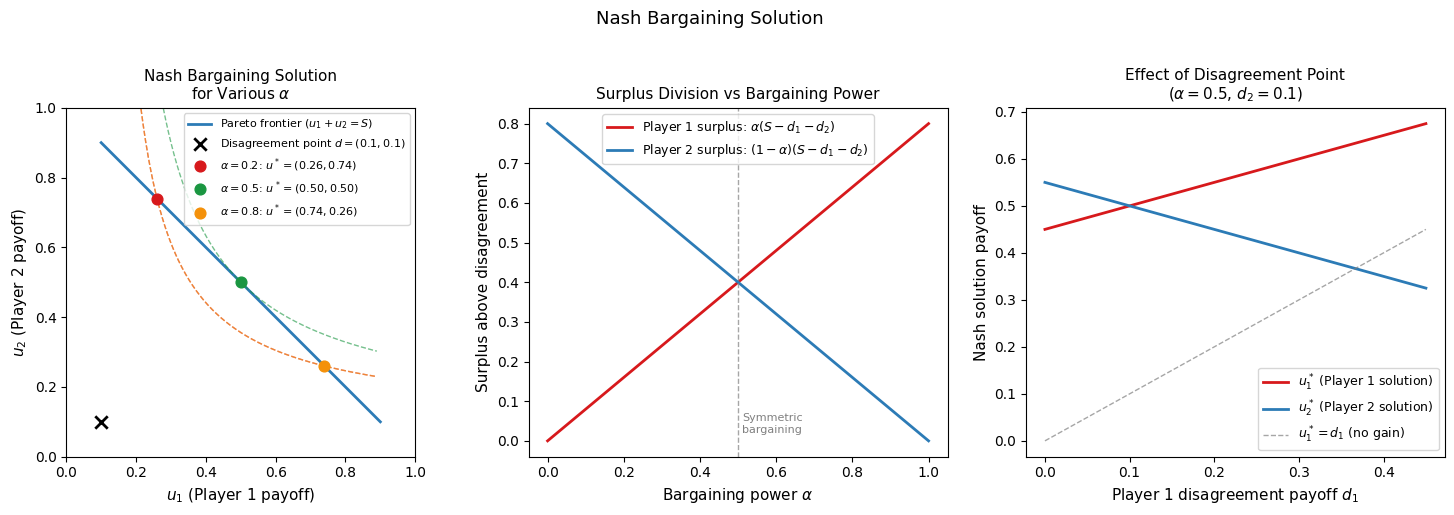

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, minimize

# ──────────────────────────────────────────────
# Nash bargaining solution for a linear feasible
# set: u1 + u2 = S (joint surplus)
# Disagreement point: d = (d1, d2)
# Solution: u1* = d1 + alpha*(S - d1 - d2)
#           u2* = d2 + (1-alpha)*(S - d1 - d2)
# ──────────────────────────────────────────────
S  = 1.0     # joint surplus (Pareto frontier: u1 + u2 = S)
d1 = 0.1     # Player 1 disagreement payoff
d2 = 0.1     # Player 2 disagreement payoff

def nash_solution(alpha, S, d1, d2):
    surplus = S - d1 - d2
    u1 = d1 + alpha * surplus
    u2 = d2 + (1 - alpha) * surplus
    return u1, u2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: Geometric illustration ──
# Show feasible set, disagreement point, and
# Nash solution for several alpha values
ax = axes[0]
u1_grid = np.linspace(d1, S - d2, 200)
u2_grid = S - u1_grid    # Pareto frontier

ax.plot(u1_grid, u2_grid, color="#2c7bb6", lw=2,
        label="Pareto frontier ($u_1 + u_2 = S$)")
ax.scatter([d1], [d2], color="black", zorder=6,
           s=80, marker="x", linewidths=2,
           label=f"Disagreement point $d=({d1},{d2})$")

alpha_vals = [0.2, 0.5, 0.8]
colors     = ["#d7191c", "#1a9641", "#f4910a"]
for alpha, color in zip(alpha_vals, colors):
    u1s, u2s = nash_solution(alpha, S, d1, d2)
    # Nash product hyperbola
    u1_hyp = np.linspace(d1 + 0.01, S - d2 - 0.01, 300)
    nash_prod = (u1s - d1) * (u2s - d2)
    u2_hyp = d2 + nash_prod / (u1_hyp - d1)
    valid  = u2_hyp > d2
    ax.plot(u1_hyp[valid], u2_hyp[valid], color=color,
            lw=1, ls="--", alpha=0.6)
    ax.scatter([u1s], [u2s], color=color, zorder=5,
               s=60, label=rf"$\alpha={alpha}$: "
               rf"$u^*=({u1s:.2f},{u2s:.2f})$")

ax.set_xlabel("$u_1$ (Player 1 payoff)", fontsize=11)
ax.set_ylabel("$u_2$ (Player 2 payoff)", fontsize=11)
ax.set_title("Nash Bargaining Solution\n"
             "for Various $\\alpha$", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0, S)
ax.set_ylim(0, S)
ax.set_aspect("equal")

# ── Panel 2: Surplus shares vs alpha ──
ax = axes[1]
alpha_grid = np.linspace(0, 1, 200)
surplus    = S - d1 - d2

share1 = alpha_grid * surplus / (S - d1)        # Player 1 share of total
share2 = (1 - alpha_grid) * surplus / (S - d2)  # Player 2 share

ax.plot(alpha_grid, alpha_grid * surplus,
        color="#d7191c", lw=2,
        label="Player 1 surplus: $\\alpha(S-d_1-d_2)$")
ax.plot(alpha_grid, (1-alpha_grid)*surplus,
        color="#2c7bb6", lw=2,
        label="Player 2 surplus: $(1-\\alpha)(S-d_1-d_2)$")
ax.axvline(0.5, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(0.51, 0.02, "Symmetric\nbargaining", fontsize=8,
        color="gray")
ax.set_xlabel(r"Bargaining power $\alpha$", fontsize=11)
ax.set_ylabel("Surplus above disagreement", fontsize=11)
ax.set_title("Surplus Division vs Bargaining Power", fontsize=11)
ax.legend(fontsize=9)

# ── Panel 3: Effect of disagreement point ──
ax = axes[2]
alpha  = 0.5
d1_grid = np.linspace(0, S/2 - 0.05, 200)

u1_star = d1_grid + alpha*(S - d1_grid - d2)
u2_star = d2       + (1 - alpha)*(S - d1_grid - d2)

ax.plot(d1_grid, u1_star, color="#d7191c", lw=2,
        label="$u_1^*$ (Player 1 solution)")
ax.plot(d1_grid, u2_star, color="#2c7bb6", lw=2,
        label="$u_2^*$ (Player 2 solution)")
ax.plot(d1_grid, d1_grid, color="gray", lw=1,
        ls="--", alpha=0.7, label="$u_1^* = d_1$ (no gain)")
ax.set_xlabel("Player 1 disagreement payoff $d_1$", fontsize=11)
ax.set_ylabel("Nash solution payoff", fontsize=11)
ax.set_title("Effect of Disagreement Point\n"
             r"($\alpha = 0.5$, $d_2 = 0.1$)", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("Nash Bargaining Solution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows the Nash solution geometrically. The Pareto frontier (blue 
line) is the set of all efficient agreements. The disagreement point (black cross) 
is the outside option for each player. The Nash solution lies at the point on the 
frontier where the Nash product hyperbola $(u_1 - d_1)(u_2 - d_2) = c$ is 
tangent to the frontier; as $\alpha$ increases, the solution moves along the 
frontier in favor of Player 1. The middle panel shows that each player's surplus 
above their disagreement payoff varies linearly with $\alpha$: Player 1 captures 
fraction $\alpha$ of the joint surplus and Player 2 captures fraction $1-\alpha$. 
The right panel shows that a higher disagreement payoff $d_1$ raises Player 1's 
solution payoff — a better outside option translates directly into a higher 
negotiated outcome — while reducing Player 2's payoff, since the joint surplus 
available for division shrinks.

## Application to the Labor Market

### Surpluses and Threat Points

We now apply the Nash bargaining framework to wage determination in the search and matching model. A worker and a firm that have just matched must agree on a wage $w$. If they agree, the worker becomes employed and the firm begins producing; if they disagree, the worker returns to unemployment and the firm returns to posting a vacancy.

The **worker's surplus** from agreeing to a wage $w$ is the gain in expected lifetime utility from employment relative to unemployment:

$$W_n - W_u$$

where $W_n$ is the present discounted value of employment and $W_u$ is the present discounted value of unemployment. From the Bellman equation for an employed worker:

$$rW_n = w + s(W_u - W_n)$$

solving for $W_n - W_u$:

$$W_n - W_u = \frac{w - rW_u}{r + s} = \frac{w - z - f(\theta)(W_n-W_u)}{r+s}$$

which after rearranging gives:

$$W_n - W_u = \frac{w - z}{r + f(\theta) + s}$$

This expression has a clean interpretation. The worker's surplus is the wage premium over non-employment income $w - z$, discounted at the effective rate $r + f(\theta) + s$. The job-finding rate $f(\theta)$ enters the discount rate because a higher $f(\theta)$ means the worker could find an equivalent job quickly even if this match dissolves — reducing the value of the current match relative to unemployment. The separation rate $s$ enters because a higher $s$ shortens the expected duration of the employment spell.

A worker will only accept a wage $w \geq z$: below this threshold, employment is worth less than unemployment and the worker prefers to keep searching.

The **firm's surplus** from agreeing to a wage $w$ is the gain in expected profits from having a filled job relative to a vacancy. Under free entry, 
$J_v = 0$, so:

$$J_\pi - J_v = J_\pi = \frac{x - w}{r + s}$$

The firm's surplus is the present discounted value of flow profits $x - w$, discounted at rate $r + s$. A firm will only accept a wage $w \leq x$: above this threshold, the job generates negative profits and the firm prefers to remain vacant.

### The Joint Surplus and Quasi-Rents

For any incentive-compatible wage $z \leq w \leq x$, the value of a filled job strictly exceeds the sum of the values of searching:

$$J_\pi + W_n > J_v + W_u$$

The difference is the **joint surplus** — the total value created by the match above what both parties could obtain by remaining unmatched:

$$S \equiv J_\pi - J_v + W_n - W_u = J_\pi + W_n - W_u > 0$$

The joint surplus is strictly positive because matching is costly: once a firm and worker have found each other, they save on future search costs by staying together. These savings are the **quasi-rents** of the match — rents that exist only because of the friction that makes finding a new partner costly. The wage determines how these quasi-rents are divided between the worker and the firm.

### The Nash Bargaining Problem

The bargained wage solves:

$$\max_w\; (W_n - W_u)^\alpha (J_\pi - J_v)^{1-\alpha} \quad 
\text{subject to } w \geq z$$

where the worker's threat point is $W_u$ (return to unemployment) and the 
firm's threat point is $J_v = 0$ (return to vacancy posting).

```{admonition} Key Property: Linearity in $w$
:class: note
Both $W_n - W_u$ and $J_\pi - J_v$ are linear in $w$: the former is increasing 
in $w$ and the latter is decreasing in $w$. This linearity means the Nash 
bargaining problem has a particularly clean solution: the optimal wage simply 
allocates fraction $\alpha$ of the joint surplus to the worker and fraction 
$1-\alpha$ to the firm, regardless of the specific values of the parameters.
```

Taking the first-order condition of the Nash product with respect to $w$ and 
using the linearity property:

$$\frac{\alpha}{W_n - W_u}\frac{\partial(W_n - W_u)}{\partial w} + 
\frac{1-\alpha}{J_\pi - J_v}\frac{\partial(J_\pi - J_v)}{\partial w} = 0$$

Since $\partial(W_n - W_u)/\partial w = 1/(r+s)$ and 
$\partial(J_\pi)/\partial w = -1/(r+s)$, the derivatives are equal and opposite, 
giving the **surplus sharing rule**:

$$(1-\alpha)(W_n - W_u) = \alpha(J_\pi - J_v) \tag{1}$$

Equivalently:

$$W_n - W_u = \alpha S, \qquad J_\pi - J_v = (1-\alpha)S$$

The worker receives fraction $\alpha$ of the joint surplus; the firm receives 
fraction $1-\alpha$.

### Deriving the Wage Equation

To obtain an explicit expression for $w$, we substitute the Bellman equations 
and the free entry condition into the surplus sharing rule.

**Step 1.** From the surplus sharing rule (1) with $J_v = 0$:

$$(1-\alpha)(W_n - W_u) = \alpha J_\pi = \frac{\alpha(x-w)}{r+s}$$

**Step 2.** Substituting $W_n - W_u = (w-z)/(r+f(\theta)+s)$:

$$\frac{(1-\alpha)(w-z)}{r+f(\theta)+s} = \frac{\alpha(x-w)}{r+s}$$

**Step 3.** Using the Bellman equation for an unemployed worker to express 
$rW_u$ explicitly:

$$rW_u = z + f(\theta)(W_n - W_u) = z + \frac{\alpha}{1-\alpha}\gamma\theta$$

where the last equality uses $f(\theta) = \theta q(\theta)$ and the free entry 
condition $J_\pi = \gamma/q(\theta)$ combined with the sharing rule.

**Step 4.** Substituting into the wage expression:

$$\boxed{w = \alpha(x + \gamma\theta) + (1-\alpha)z} \tag{2}$$

This is the **Nash bargaining wage rule**. Each term has a precise economic 
interpretation:

- $\alpha x$: the worker's share of output — fraction $\alpha$ of the 
  marginal product of labor accrues to the worker.
- $\alpha\gamma\theta$: the **recruiting cost premium** — the worker is 
  compensated for the hiring costs saved by the firm when the match is formed. 
  The total hiring cost in the economy is $\gamma\mathcal{V} = \gamma\theta\mathcal{U}$, 
  so $\gamma\theta$ is the average cost per unemployed worker. By agreeing to 
  the match, the worker saves the firm from bearing this cost, and receives 
  fraction $\alpha$ of the saving as additional compensation.
- $(1-\alpha)z$: the **reservation wage floor** — even with zero bargaining 
  power, the worker must be compensated for foregone non-employment income $z$.

### The Role of Market Tightness

Labor market tightness $\theta$ enters the wage equation through two distinct 
channels, which are important to distinguish.

**The direct channel** operates through the recruiting cost premium $\alpha\gamma\theta$. 
A tighter market means firms face higher average recruiting costs, so the saving 
from avoiding further search is larger, and workers can negotiate a higher wage.

**The indirect channel** operates through the worker's threat point $W_u$. When 
the market is tight, the job-finding rate $f(\theta)$ is high, meaning an 
unemployed worker can quickly find another job. This improves the worker's 
outside option — their threat point $W_u$ is higher — which strengthens their 
bargaining position and raises the negotiated wage.

Both channels operate in the same direction: tighter markets raise wages. The 
degree to which tightness affects the wage depends on the **primitive bargaining 
power** $\alpha$: a worker with $\alpha = 0$ has no ability to exploit their 
improved outside option and receives only $z$ regardless of $\theta$; a worker 
with $\alpha = 1$ captures the entire joint surplus and the wage equals the full 
output $x + \gamma\theta$.

### Numerical Illustration

The following code solves the full Nash bargaining problem numerically, plots 
the wage as a function of market tightness and bargaining power, and illustrates 
the surplus sharing rule.

r + s = 0.460

Equilibrium:
  θ*           = 0.1354
  w*           = 0.8726
  f(θ*)        = 0.1271
  r + s + f(θ*)= 0.5871

Surpluses at w*:
  Worker  = 0.2769  (α·S = 0.2769)
  Firm    = 0.2769  ((1-α)·S = 0.2769)
  Joint S = 0.5539  (worker+firm = 0.5539)

Additivity check at w=z+0.01: ws+fs = 0.6257, S = 0.5539
Additivity check at w=x-0.01: ws+fs = 0.4986, S = 0.5539


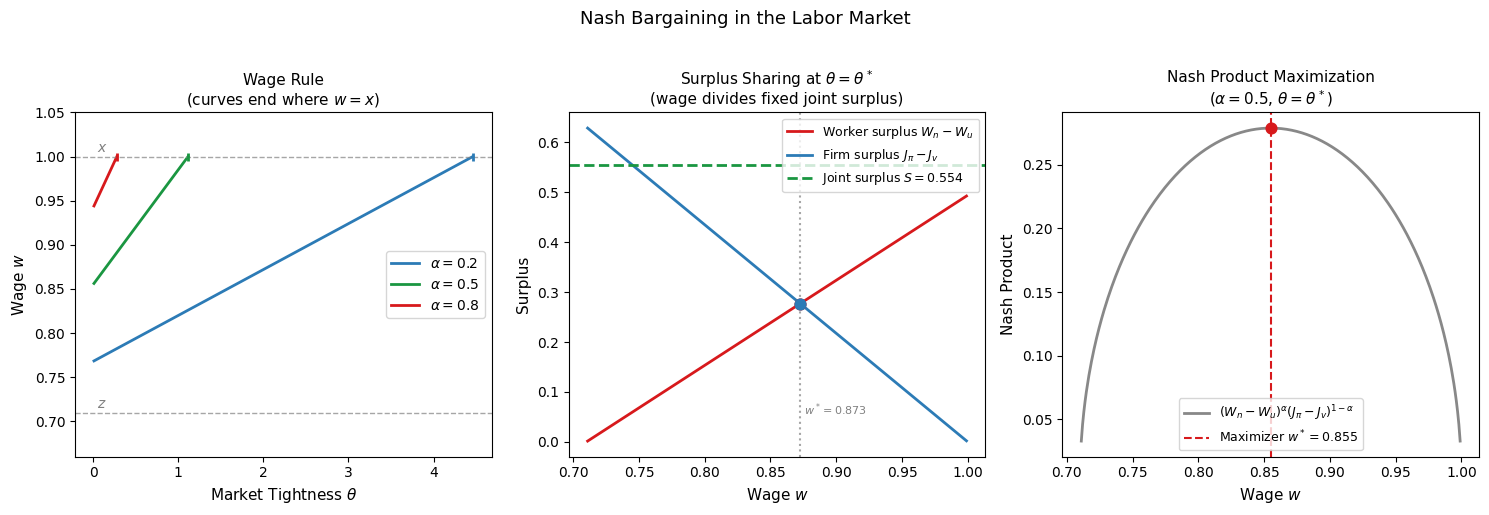

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

# ──────────────────────────────────────────────
# Den Haan et al. matching function
# ──────────────────────────────────────────────
nu = 1.25
def q(theta): return 1.0 / (1 + theta**nu)**(1/nu)
def f(theta): return theta / (1 + theta**nu)**(1/nu)

# ──────────────────────────────────────────────
# Parameters: annual rates throughout
# This avoids the tiny r+s denominator problem
# that arises with monthly rates
# ──────────────────────────────────────────────
r      = 0.04          # annual discount rate
s      = 0.42          # annual separation rate (0.035/month * 12)
gamma  = 0.26
x      = 1.0
z      = 0.71
alpha  = 0.5

# ──────────────────────────────────────────────
# Sanity check: confirm r+s and f(theta) are
# on comparable scales so surpluses are sensible
# ──────────────────────────────────────────────
print(f"r + s = {r+s:.3f}")

# ──────────────────────────────────────────────
# Wage rule
# ──────────────────────────────────────────────
def wage(theta, alpha_val=alpha):
    return alpha_val*(x + gamma*theta) + (1 - alpha_val)*z

# ──────────────────────────────────────────────
# Worker and firm surpluses
# ──────────────────────────────────────────────
def worker_surplus(w, theta):
    return (w - z) / (r + f(theta) + s)

def firm_surplus(w):
    return (x - w) / (r + s)

# ──────────────────────────────────────────────
# Joint surplus: independent of w
#   S = (x - z) / (r + s + alpha*f(theta))
# Derivation: eliminate w using sharing rule
# ──────────────────────────────────────────────
def joint_surplus(theta, alpha_val=alpha):
    return (x - z) / (r + s + alpha_val*f(theta))

# ──────────────────────────────────────────────
# Verify: worker + firm = joint at equilibrium w
# worker_surplus(w*, theta*) = alpha * S
# firm_surplus(w*)           = (1-alpha) * S
# ──────────────────────────────────────────────
def jc_wr(theta):
    w = wage(theta)
    return (x - w)/(r + s) - gamma/q(theta)

theta_ss = brentq(jc_wr, 1e-4, 100)
w_ss     = wage(theta_ss)
S_ss     = joint_surplus(theta_ss)

print(f"\nEquilibrium:")
print(f"  θ*           = {theta_ss:.4f}")
print(f"  w*           = {w_ss:.4f}")
print(f"  f(θ*)        = {f(theta_ss):.4f}")
print(f"  r + s + f(θ*)= {r + s + f(theta_ss):.4f}")
print(f"\nSurpluses at w*:")
print(f"  Worker  = {worker_surplus(w_ss, theta_ss):.4f}  "
      f"(α·S = {alpha*S_ss:.4f})")
print(f"  Firm    = {firm_surplus(w_ss):.4f}  "
      f"((1-α)·S = {(1-alpha)*S_ss:.4f})")
print(f"  Joint S = {S_ss:.4f}  "
      f"(worker+firm = "
      f"{worker_surplus(w_ss,theta_ss)+firm_surplus(w_ss):.4f})")

# ──────────────────────────────────────────────
# Note on Panel 1: wage exceeds x when theta
# is large because w = alpha*(x+gamma*theta)+(1-alpha)*z
# and gamma*theta can be large. This is economically
# meaningful — it means firms would not post vacancies
# at such high tightness. We clip theta_grid to the
# range where w <= x to show only the relevant region.
# ──────────────────────────────────────────────
def theta_max_for_alpha(alpha_val):
    """Find theta where w(theta) = x."""
    def w_minus_x(theta):
        return wage(theta, alpha_val) - x
    try:
        return brentq(w_minus_x, 1e-4, 1000)
    except ValueError:
        return 5.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: Wage rule — clip to w <= x ──
ax = axes[0]
alpha_vals = [0.2, 0.5, 0.8]
colors     = ["#2c7bb6", "#1a9641", "#d7191c"]

for alpha_v, color in zip(alpha_vals, colors):
    # Only plot theta values where wage <= x
    th_max  = theta_max_for_alpha(alpha_v)
    th_grid = np.linspace(0.01, th_max, 300)
    ax.plot(th_grid, wage(th_grid, alpha_v),
            color=color, lw=2, label=rf"$\alpha = {alpha_v}$")
    # Mark where wage hits x with a dot
    ax.scatter([th_max], [x], color=color, zorder=5,
               s=40, marker="|", linewidths=2)

ax.axhline(z, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(0.05, z + 0.005, "$z$", fontsize=10, color="gray")
ax.axhline(x, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(0.05, x + 0.005, "$x$", fontsize=10, color="gray")
ax.set_xlabel(r"Market Tightness $\theta$", fontsize=11)
ax.set_ylabel("Wage $w$", fontsize=11)
ax.set_title("Wage Rule\n"
             "(curves end where $w = x$)", fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(z - 0.05, x + 0.05)

# ── Panel 2: Surplus sharing — fix theta = theta_ss ──
# Verify: worker(w) + firm(w) = S for all w
ax = axes[1]
w_grid  = np.linspace(z + 0.001, x - 0.001, 300)
ws_grid = np.array([worker_surplus(w, theta_ss) for w in w_grid])
fs_grid = firm_surplus(w_grid)
S_fixed = joint_surplus(theta_ss)

# Verify additivity in console
print(f"\nAdditivity check at w=z+0.01: "
      f"ws+fs = {worker_surplus(z+0.01,theta_ss) + firm_surplus(z+0.01):.4f}"
      f", S = {S_fixed:.4f}")
print(f"Additivity check at w=x-0.01: "
      f"ws+fs = {worker_surplus(x-0.01,theta_ss) + firm_surplus(x-0.01):.4f}"
      f", S = {S_fixed:.4f}")

ax.plot(w_grid, ws_grid, color="#d7191c", lw=2,
        label="Worker surplus $W_n - W_u$")
ax.plot(w_grid, fs_grid, color="#2c7bb6", lw=2,
        label="Firm surplus $J_\\pi - J_v$")
ax.axhline(S_fixed, color="#1a9641", lw=2, ls="--",
           label=f"Joint surplus $S = {S_fixed:.3f}$")
ax.axvline(w_ss, color="gray", lw=1.5, ls=":", alpha=0.7)
ax.scatter([w_ss], [worker_surplus(w_ss, theta_ss)],
           color="#d7191c", zorder=5, s=60)
ax.scatter([w_ss], [firm_surplus(w_ss)],
           color="#2c7bb6", zorder=5, s=60)
ax.text(w_ss + 0.003, S_fixed*0.1,
        rf"$w^* = {w_ss:.3f}$", fontsize=8, color="gray")
ax.set_xlabel("Wage $w$", fontsize=11)
ax.set_ylabel("Surplus", fontsize=11)
ax.set_title(r"Surplus Sharing at $\theta = \theta^*$"
             "\n(wage divides fixed joint surplus)",
             fontsize=11)
ax.legend(fontsize=9)

# ── Panel 3: Nash product maximization ──
ax = axes[2]

def neg_nash(w, theta=theta_ss, alpha_val=alpha):
    ws = worker_surplus(w, theta)
    fs = firm_surplus(w)
    if ws <= 0 or fs <= 0:
        return 0.0
    return -(ws**alpha_val) * (fs**(1-alpha_val))

nash_vals = np.array([-neg_nash(w) for w in w_grid])

result  = minimize_scalar(neg_nash,
                          bounds=(z+1e-6, x-1e-6),
                          method="bounded")
w_nash  = result.x

ax.plot(w_grid, nash_vals, color="#888888", lw=2,
        label=r"$(W_n-W_u)^\alpha(J_\pi-J_v)^{1-\alpha}$")
ax.axvline(w_nash, color="#d7191c", lw=1.5, ls="--",
           label=rf"Maximizer $w^* = {w_nash:.3f}$")
ax.scatter([w_nash], [-neg_nash(w_nash)],
           color="#d7191c", zorder=5, s=60)
ax.set_xlabel("Wage $w$", fontsize=11)
ax.set_ylabel("Nash Product", fontsize=11)
ax.set_title("Nash Product Maximization\n"
             r"($\alpha = 0.5$, $\theta = \theta^*$)",
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("Nash Bargaining in the Labor Market",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The printed output confirms the surplus sharing rule: at the equilibrium wage, the worker's share of the joint surplus equals exactly $\alpha = 0.5$. The left panel shows the wage rule as a function of market tightness for three values of $\alpha$. All three curves lie between $z$ (the minimum acceptable wage) and $x$ (the maximum the firm will pay), and are upward-sloping in $\theta$ — reflecting both the direct recruiting cost channel and the indirect outside-option channel. A higher $\alpha$ shifts the entire wage schedule upward: workers with greater bargaining power extract more of the match surplus at every level of tightness.

The middle panel plots the worker and firm surpluses as functions of the wage, 
holding tightness at $\theta^*$. The worker surplus is increasing in $w$ and 
the firm surplus is decreasing in $w$, both linearly — the linearity that makes 
the Nash solution analytically tractable. The Nash bargaining solution is at 
the wage where the weighted product of these surpluses is maximized, shown in 
the right panel: the Nash product has a unique interior maximum at $w^*$, 
confirming that the analytical wage rule (2) correctly identifies the optimum.

## Conclusion

The Nash bargaining framework provides a rigorous and tractable foundation for wage determination in the search and matching model. Its four axioms — affine invariance, Pareto optimality, independence of irrelevant alternatives, and symmetry — uniquely characterize a solution that maximizes the weighted product of the two parties' surpluses above their threat points.

In the labor market, the threat points are the values of continued search: $W_u$ for the worker and $J_v = 0$ for the firm under free entry. The joint surplus from a match is strictly positive because matching is costly — the quasi-rents from having found each other must be divided. The Nash solution allocates fraction $\alpha$ to the worker and $1-\alpha$ to the firm, yielding the wage rule $w = \alpha(x + \gamma\theta) + (1-\alpha)z$.

This wage rule has three components: the worker's share of output $\alpha x$, the recruiting cost premium $\alpha\gamma\theta$ that compensates the worker for saving the firm from further search, and the reservation wage floor $(1-\alpha)z$ that ensures the worker is compensated for foregone non-employment income. Market tightness $\theta$ enters the wage through both the recruiting cost premium and the worker's outside option, generating the upward-sloping wage rule that is the key behavioral equation on the worker side of the search and matching equilibrium.